# EDA + Lista de Leakage — Bank Marketing

**Etapa E1 · Eng. de Dados.** Objetivo: entender a base *antes* de modelar, expor o
desbalanceamento e os valores ausentes disfarçados, e **identificar features de vazamento
temporal (leakage)** a serem removidas.

- **Base:** `data/kaggle/bank-additional-full.csv` (41.188 × 21) — ver
  [dicionário de dados](../docs/data-dictionary.md).
- **Atenção:** esta variante (*bank-additional*) **não tem coluna `balance` (saldo)**;
  onde o projeto fala em "saldo" usamos proxies (`default`, `job`, `loan`).

## 1. Setup e carga

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
log = logging.getLogger("01-eda")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
DATA = Path("../data/kaggle/bank-additional-full.csv")
if not DATA.exists():
    raise FileNotFoundError(f"Base não encontrada em {DATA.resolve()}")
df = pd.read_csv(DATA, sep=";")
log.info("Base carregada: %d linhas x %d colunas", *df.shape)
df.head()

INFO 01-eda: Base carregada: 41188 linhas x 21 colunas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Visão geral — shape, tipos e estatísticas

In [3]:
print("Linhas, colunas:", df.shape)
df.dtypes.to_frame("dtype")

Linhas, colunas: (41188, 21)


,dtype
age,int64
job,str
marital,str
education,str
default,str
housing,str
loan,str
contact,str
month,str
day_of_week,str


Estatísticas das numéricas. **Cuidado:** `duration` e `pdays` aparecem aqui mas são
traiçoeiras — `duration` é leakage (seção 7) e `pdays` tem 96% de valores `999`
(sentinela "nunca contatado"), o que torna média/quartis sem sentido (seção 6).

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


### Cardinalidade das categóricas

In [5]:
cat_cols = df.select_dtypes(include="object").columns.drop("y")
df[cat_cols].nunique().sort_values(ascending=False).to_frame("n_categorias")

/tmp/ipykernel_113469/2108465091.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.drop("y")


,n_categorias
job,12
month,10
education,8
day_of_week,5
marital,4
default,3
loan,3
housing,3
poutcome,3
contact,2


## 3. Valores ausentes — o `"unknown"` disfarçado

Esta base **não tem `NaN`**: o ausente vem como a string `"unknown"`. Um `isna()` ingênuo
reportaria 0% de missing. Convertendo `"unknown" → NA` o quadro real aparece.

In [6]:
df = df.replace("unknown", pd.NA)
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
pd.DataFrame({"n_missing": miss, "pct_%": (miss / len(df) * 100).round(2)})

,n_missing,pct_%
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


`housing` e `loan` têm exatamente o mesmo nº de ausentes — vamos confirmar se são as
**mesmas linhas** (registros onde o crédito não foi capturado), o que define se imputamos
os dois juntos.

In [7]:
both = (df.housing.isna() & df.loan.isna()).sum()
print(f"housing NA: {df.housing.isna().sum()} | loan NA: {df.loan.isna().sum()} | ambos NA na MESMA linha: {both}")

housing NA: 990 | loan NA: 990 | ambos NA na MESMA linha: 990


## 4. Variável alvo `y` — desbalanceamento

Número-manchete da base: apenas **~11% de `yes`**. Isso obriga métricas sensíveis a
desbalanceamento (PR-AUC, recall, F1) — *accuracy* é enganosa aqui.

y
no     88.73
yes    11.27


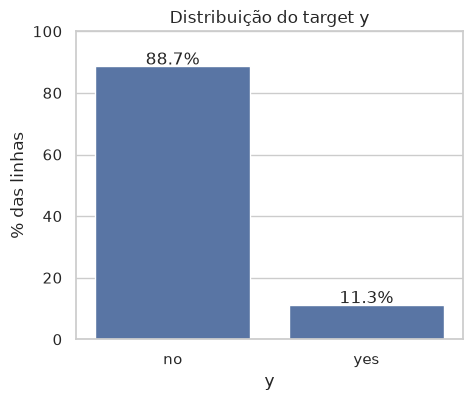

In [8]:
y_dist = df.y.value_counts(normalize=True).mul(100).round(2)
print(y_dist.to_string())
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=y_dist.index, y=y_dist.values, ax=ax)
for i, v in enumerate(y_dist.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set(title="Distribuição do target y", ylabel="% das linhas", xlabel="y", ylim=(0, 100))
plt.show()

## 5. Distribuições e relação com o target

### 5.1 `age` por `y`

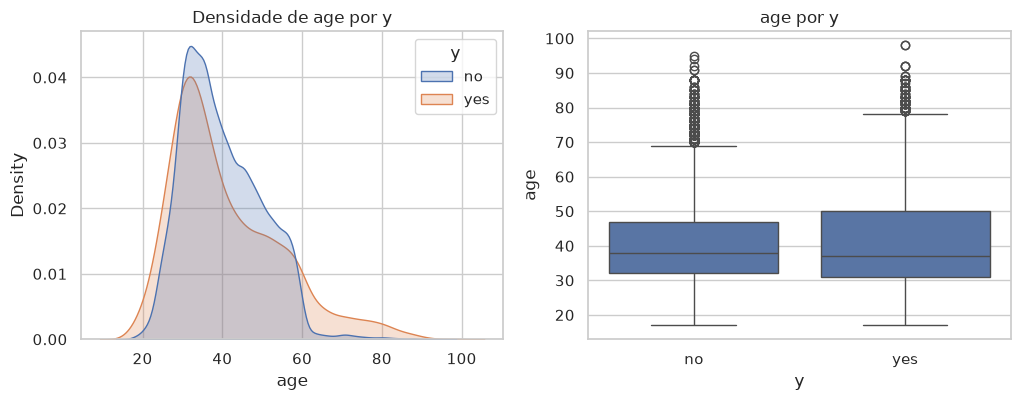

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="age", hue="y", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Densidade de age por y")
sns.boxplot(data=df, x="y", y="age", ax=axes[1])
axes[1].set_title("age por y")
plt.show()

### 5.2 Conversão por `job`

Taxa de `yes` por profissão vs. a média global (11,3%) — insumo para o contexto sintético
(proxy de renda/segmento).

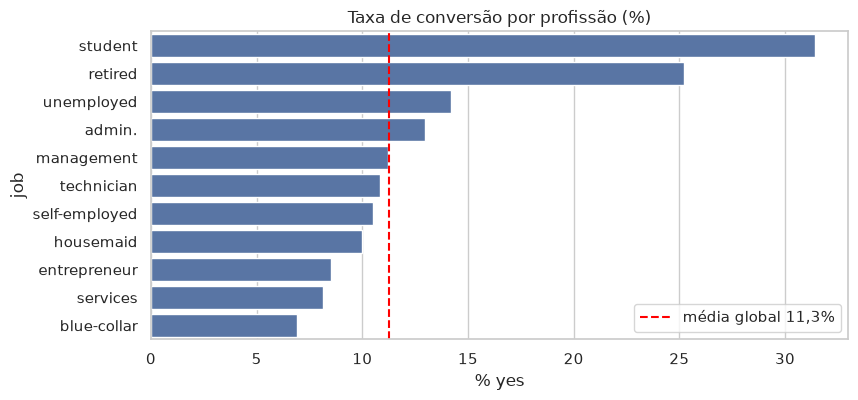

In [10]:
df["y_bin"] = (df.y == "yes").astype(int)
conv_job = df.groupby("job", dropna=False).y_bin.mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=conv_job.values, y=conv_job.index.astype(str), ax=ax)
ax.axvline(11.27, ls="--", color="red", label="média global 11,3%")
ax.set(title="Taxa de conversão por profissão (%)", xlabel="% yes")
ax.legend()
plt.show()

### 5.3 `default` / `housing` / `loan` — proxies de capacidade financeira

⚠️ **Achado crítico para a segmentação sintética (E2):** `default = "yes"` tem **apenas 3
linhas** em toda a base. Logo, "negativado = `default==yes`" é um proxy praticamente vazio —
o sinal de inadimplência aqui está majoritariamente em `default = "unknown"`. A segmentação
do braço *renegociação* precisa ser revista (usar `loan`, ou tratar como segmento sintético).

In [11]:
for c in ["default", "housing", "loan"]:
    print(f"{c:8s}:", df[c].value_counts(dropna=False).to_dict())
print()
print("Conversão (% yes) por default:")
print(df.groupby(df.default.fillna("unknown")).y_bin.mean().mul(100).round(2).to_string())

default : {'no': 32588, nan: 8597, 'yes': 3}
housing : {'yes': 21576, 'no': 18622, nan: 990}
loan    : {'no': 33950, 'yes': 6248, nan: 990}

Conversão (% yes) por default:
default
no         12.88
unknown     5.15
yes         0.00


## 6. `pdays` — sentinela `999`

`999` significa "cliente nunca contatado antes" — é categórico disfarçado de numérico.
Separamos em uma flag booleana `foi_contatado_antes` para não poluir estatísticas e modelos.

In [12]:
print("share de pdays == 999:", round((df.pdays == 999).mean(), 4))
df["foi_contatado_antes"] = df.pdays != 999
print("\nConversão (% yes) por foi_contatado_antes:")
print(df.groupby("foi_contatado_antes").y_bin.mean().mul(100).round(2).to_string())

share de pdays == 999: 0.9632

Conversão (% yes) por foi_contatado_antes:
foi_contatado_antes
False     9.26
True     63.83


## 7. Vazamento temporal (leakage)

### 7.1 `duration` — a prova

`duration` (duração da ligação) só é conhecida **depois** que a ligação termina — quando o
desfecho já é sabido. O gráfico mostra a separação gritante (média 221s para `no` vs 553s
para `yes`; correlação 0,40). **Deve ser removida** do conjunto de modelagem.

y
no     220.8
yes    553.2
corr(duration, y): 0.405


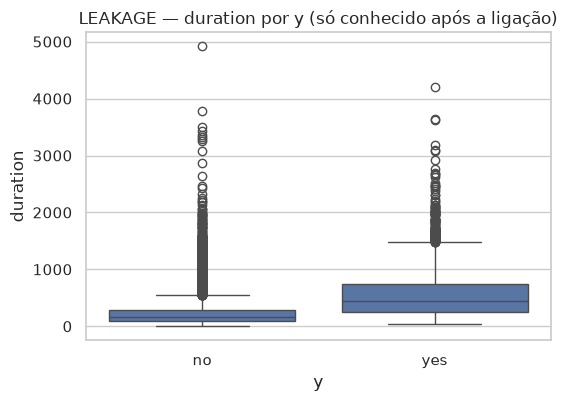

In [13]:
print(df.groupby("y").duration.mean().round(1).to_string())
print("corr(duration, y):", round(df.duration.corr(df.y_bin), 3))
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="y", y="duration", ax=ax)
ax.set_title("LEAKAGE — duration por y (só conhecido após a ligação)")
plt.show()

### 7.2 Indicadores macro — colinearidade e viés temporal

`emp.var.rate`, `euribor3m` e `nr.employed` são quase perfeitamente colineares (0,91–0,97):
codificam *quando* a campanha rodou (regime econômico 2008–2010), não o cliente. Risco de o
modelo aprender "a época" em vez de propensão → **candidatos secundários a leakage temporal**.

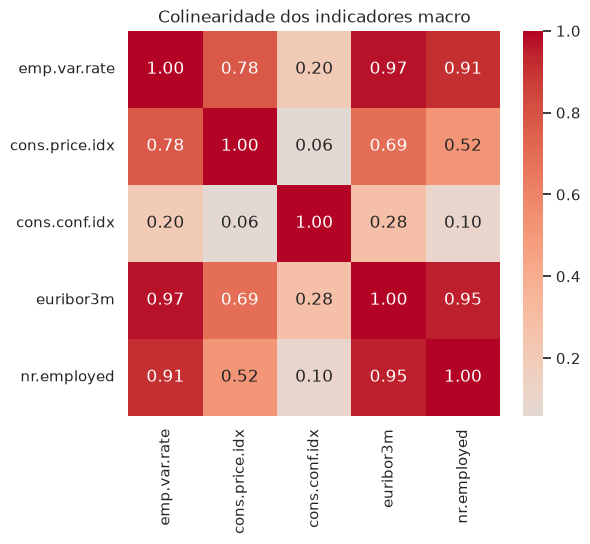

In [14]:
macro = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[macro].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Colinearidade dos indicadores macro")
plt.show()

## 8. Associações entre todas as variáveis (dython)

`dython.associations` lida com tipos mistos: **Cramér's V** para categórica×categórica e
**correlation ratio (η)** para categórica×numérica — superior a um `.corr()` que ignoraria as
categóricas. Repare na linha/coluna de `duration` vs `y`: a associação alta é justamente o
leakage.

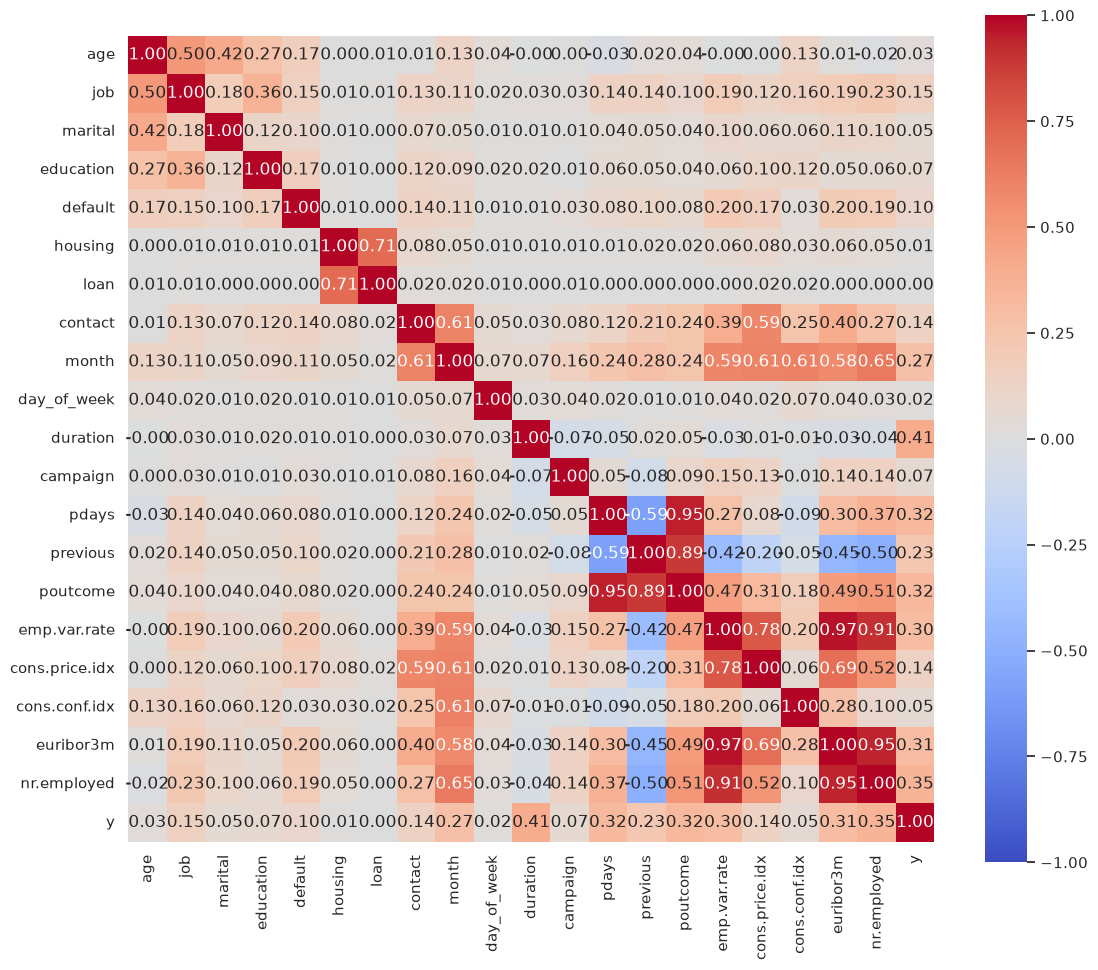

In [15]:
assoc = associations(
    df.drop(columns=["y_bin", "foi_contatado_antes"]),
    nom_nom_assoc="cramer",
    nan_strategy="replace",
    nan_replace_value="ausente",
    figsize=(13, 11),
    cmap="coolwarm",
)
plt.show()

## 9. Features candidatas a leakage

| # | Feature | Veredito | Justificativa |
|---|---------|----------|---------------|
| 1 | `duration` | **Remover** | Só existe após a ligação; prevê o passado com info do futuro. Corr 0,40 com `y`; média 221s (no) × 553s (yes). |
| 2 | `pdays` (=999) | **Transformar** | 96% sentinela `999`; usar como flag `foi_contatado_antes`, não como número cru. |
| 3 | `emp.var.rate`, `euribor3m`, `nr.employed` | **Vigiar / regularizar** | Colineares (0,91–0,97) e proxies do período temporal; risco de o modelo aprender o regime econômico. Avaliar manter só 1 ou nenhum. |
| 4 | `poutcome` / `previous` | **Avaliar** | Legítimos (campanha anterior), mas confirmar que não carregam o desfecho atual. |

## 10. Conclusões e próximos passos

- Base com **~11% de positivos** → métricas sensíveis a desbalanceamento.
- Ausentes disfarçados de `"unknown"`; `default` (21%) e `education` (4%) os mais afetados.
- **`default="yes"` quase inexistente (3 linhas)** → revisar o proxy de "negativado" da E2.
- **`duration` é o leakage nº 1** e sai do conjunto de modelagem.
- `pdays=999` vira flag; indicadores macro ficam sob vigilância (colinearidade/viés temporal).

➡️ Próximo: **#26** — gerar `data/processed/modeling_table.parquet` (sem `duration`) e o
loader `src/bankmarketing/data.py`, consumindo esta lista de leakage.